In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройка визуализации
sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# Фиксация сида для воспроизводимости
np.random.seed(42)

# Генерация данных: длительность сессии в минутах
# Группа A (Контроль): среднее 15 мин, стандартное отклонение 5
group_a = np.random.normal(loc=15, scale=5, size=500)

# Группа B (Тест - с геймификацией): среднее 17.1 мин (рост ~13%), отклонение 5.5
group_b = np.random.normal(loc=17.1, scale=5.5, size=500)

# Объединение в DataFrame
df = pd.DataFrame({
    'user_id': range(1, 1001),
    'group': ['A']*500 + ['B']*500,
    'session_duration': np.concatenate([group_a, group_b])
})

# Ограничение минимальных значений (время не может быть отрицательным)
df['session_duration'] = df['session_duration'].clip(lower=0.5)

print("Первые 5 строк датасета:")
print(df.head())

Первые 5 строк датасета:
   user_id group  session_duration
0        1     A         17.483571
1        2     A         14.308678
2        3     A         18.238443
3        4     A         22.615149
4        5     A         13.829233



Описательная статистика:
       count       mean       std       min        25%        50%        75%  \
group                                                                          
A      500.0  15.037603  4.895529  0.500000  11.498463  15.063986  18.183916   
B      500.0  17.275044  5.378985  2.267123  13.825895  17.256924  20.681833   

             max  
group             
A      34.263657  
B      31.578101  


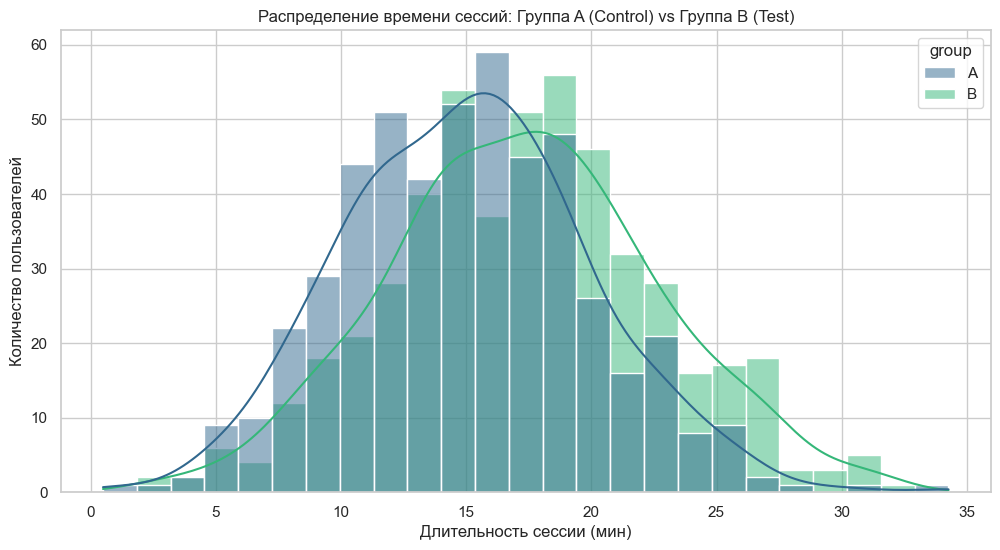

C:\Users\krist\AppData\Local\Temp\ipykernel_37568\863472375.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='group', y='session_duration', palette='Set2')


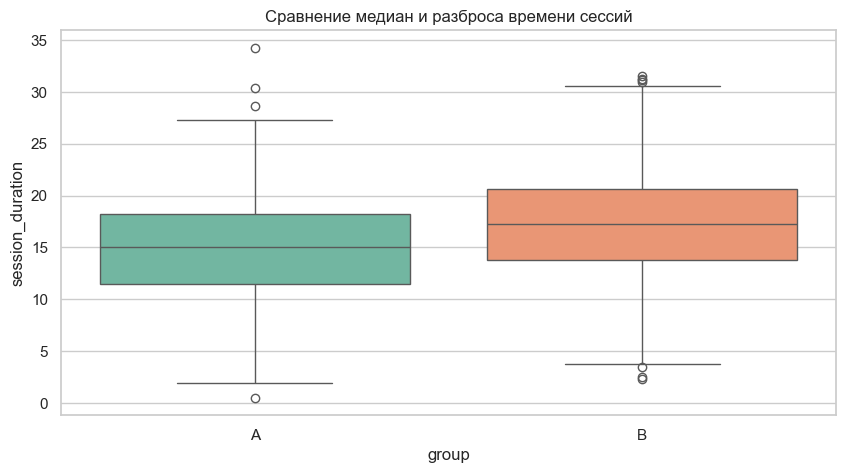

In [3]:
# Описательная статистика по группам
stats_summary = df.groupby('group')['session_duration'].describe()
print("\nОписательная статистика:")
print(stats_summary)

# Визуализация распределения
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='session_duration', hue='group', kde=True, palette='viridis')
plt.title('Распределение времени сессий: Группа A (Control) vs Группа B (Test)')
plt.xlabel('Длительность сессии (мин)')
plt.ylabel('Количество пользователей')
plt.show()

# Boxplot для поиска выбросов
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='group', y='session_duration', palette='Set2')
plt.title('Сравнение медиан и разброса времени сессий')
plt.show()

In [4]:
# Тест Шапиро-Уилка на нормальность
shapiro_a = stats.shapiro(df[df['group'] == 'A']['session_duration'])
shapiro_b = stats.shapiro(df[df['group'] == 'B']['session_duration'])

print(f"Тест на нормальность (p-value): Группа А = {shapiro_a.pvalue:.4f}, Группа В = {shapiro_b.pvalue:.4f}")

# Выбор критерия: 
# Поскольку выборки большие (n=500) и распределение близко к нормальному,
# используем T-критерий Уэлча (не требует равенства дисперсий).

t_stat, p_val = stats.ttest_ind(
    df[df['group'] == 'A']['session_duration'], 
    df[df['group'] == 'B']['session_duration'], 
    equal_var=False
)

print(f"\nРезультаты T-теста:")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p_val:.4e}")

Тест на нормальность (p-value): Группа А = 0.3604, Группа В = 0.6757

Результаты T-теста:
t-statistic = -6.8788
p-value = 1.0692e-11


In [5]:
# Расчет разницы средних
mean_a = df[df['group'] == 'A']['session_duration'].mean()
mean_b = df[df['group'] == 'B']['session_duration'].mean()
uplift = (mean_b - mean_a) / mean_a * 100

print(f"Среднее время сессии (A): {mean_a:.2f} мин")
print(f"Среднее время сессии (B): {mean_b:.2f} мин")
print(f"Относительный прирост (Uplift): {uplift:.2f}%")

# Вывод
alpha = 0.05
if p_val < alpha:
    print("\nИТОГ: Нулевая гипотеза отвергнута. Изменения статистически значимы.")
else:
    print("\nИТОГ: Не удалось отвергнуть нулевую гипотезу. Разница статистически не значима.")

Среднее время сессии (A): 15.04 мин
Среднее время сессии (B): 17.28 мин
Относительный прирост (Uplift): 14.88%

ИТОГ: Нулевая гипотеза отвергнута. Изменения статистически значимы.
